# Projeto de Consultoria Estatística

# Introdução

A precificação de imóveis constitui um dos principais desafios enfrentados pelo mercado imobiliário, uma vez que o valor de venda é influenciado por diversos fatores estruturais, construtivos e funcionais. A definição de preços baseada apenas na experiência do corretor ou em comparações informais pode resultar em imóveis supervalorizados ou subvalorizados, comprometendo tanto a competitividade quanto a tomada de decisão por parte de compradores, vendedores e investidores.

Nesse contexto, técnicas de Estatística e Ciência de Dados tornam-se importantes ferramentas de apoio à precificação, permitindo identificar quais características dos imóveis exercem maior influência sobre o preço de venda e construir modelos capazes de realizar estimativas de forma objetiva e fundamentada em dados.

Como problema de consultoria, este projeto busca responder à seguinte questão:

> **Quais características dos imóveis influenciam significativamente o preço de venda e como utilizar essas informações para desenvolver um sistema capaz de estimar automaticamente o valor de novos imóveis?**

Para responder a essa questão, foi utilizada a base de dados **House Prices: Advanced Regression Techniques**, disponibilizada na plataforma Kaggle, contendo informações estruturais de imóveis residenciais localizados na cidade de Ames, Iowa (Estados Unidos).

Inicialmente, foi realizada uma análise exploratória dos dados para compreender o comportamento das variáveis e identificar possíveis relações com o preço de venda. Em seguida, foram ajustados Modelos Lineares Generalizados (MLG), considerando diferentes distribuições probabilísticas, até a definição do modelo mais adequado para representar os dados.

Como entregável do projeto, foi desenvolvido um sistema interativo em Streamlit capaz de estimar o preço de venda de novos imóveis a partir das características informadas pelo usuário. Dessa forma, o trabalho integra técnicas de Estatística, Ciência de Dados e desenvolvimento de produtos de dados, oferecendo uma ferramenta de apoio à tomada de decisão no mercado imobiliário.

In [1]:
# ==========================================================
# PROJETO DE CONSULTORIA ESTATÍSTICA
# HOUSE PRICES - KAGGLE
# MODELOS LINEARES GENERALIZADOS (MLG)
# ==========================================================

# ==========================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ==========================================================

# Sistema
import os
import warnings
warnings.filterwarnings("ignore")

# Manipulação de dados
import pandas as pd
import numpy as np
import datetime

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Estatística
from scipy import stats
from IPython.display import display

# Modelagem estatística
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Avaliação dos modelos
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Configuração dos gráficos
sns.set_theme(style="whitegrid")

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


# 1. Importação da Base de Dados

In [2]:
# ==========================================================
# IMPORTAÇÃO DA BASE DE DADOS
# ==========================================================

from pathlib import Path
import pandas as pd

# Caminho da base de dados
caminho_dados = Path("../dados/train.csv")

# Leitura da base
dados = pd.read_csv(caminho_dados)

# Visualizar as primeiras linhas
dados.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# 2. Conhecendo a Base de Dados

In [3]:
# ==========================================================
# CONHECENDO A BASE DE DADOS
# ==========================================================

# Dimensão da base
print("Dimensão da base:")
print(dados.shape)

# Informações gerais
print("\nInformações da base:")
dados.info()

# Primeiras linhas
print("\nPrimeiras 5 linhas:")
display(dados.head())

# Últimas linhas
print("\nÚltimas 5 linhas:")
display(dados.tail())

Dimensão da base:
(1460, 81)

Informações da base:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Últimas 5 linhas:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [4]:
# ==========================================================
# ESTATÍSTICAS DESCRITIVAS INICIAIS
# ==========================================================

dados.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
# ==========================================================
# TIPOS DAS VARIÁVEIS
# ==========================================================

dados.dtypes

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

# 3. Avaliação da Qualidade dos Dados

In [5]:
# ==========================================================
# VERIFICAÇÃO DE VALORES AUSENTES
# ==========================================================

# Quantidade de valores ausentes por variável
valores_nulos = dados.isnull().sum()

# Exibir apenas variáveis que possuem valores ausentes
valores_nulos = valores_nulos[valores_nulos > 0]

valores_nulos.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [7]:
# ==========================================================
# PERCENTUAL DE VALORES AUSENTES
# ==========================================================

percentual_nulos = (
    dados.isnull().sum() / len(dados)
) * 100

percentual_nulos = percentual_nulos[
    percentual_nulos > 0
]

percentual_nulos.sort_values(ascending=False)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

In [6]:
# ==========================================================
# DUPLICATAS
# ==========================================================

print("Quantidade de linhas duplicadas:")

print(dados.duplicated().sum())

Quantidade de linhas duplicadas:
0


In [7]:
# ==========================================================
# DIMENSÃO DA BASE
# ==========================================================

print(f"Número de linhas: {dados.shape[0]}")
print(f"Número de colunas: {dados.shape[1]}")

Número de linhas: 1460
Número de colunas: 81


In [8]:
# ==========================================================
# RESUMO DA QUALIDADE DOS DADOS
# ==========================================================

print(f"Número de observações: {dados.shape[0]}")
print(f"Número de variáveis: {dados.shape[1]}")

print(f"\nValores ausentes: {dados.isnull().sum().sum()}")

print(f"Linhas duplicadas: {dados.duplicated().sum()}")

Número de observações: 1460
Número de variáveis: 81

Valores ausentes: 7829
Linhas duplicadas: 0


In [11]:
# ==========================================================
# TABELA DE VALORES AUSENTES
# ==========================================================

tabela_nulos = pd.DataFrame({
    "Valores Ausentes": dados.isnull().sum(),
    "Percentual (%)": (dados.isnull().mean()*100).round(2)
})

tabela_nulos = (
    tabela_nulos
    .query("`Valores Ausentes` > 0")
    .sort_values("Percentual (%)", ascending=False)
)

tabela_nulos

,Valores Ausentes,Percentual (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


# 4. Limpeza e Tratamento dos Dados

Antes da construção do modelo estatístico, foi realizada a etapa de limpeza e tratamento dos dados, com o objetivo de garantir uma base consistente e adequada para as análises. Esse processo é fundamental para reduzir problemas decorrentes de dados incompletos ou inconsistentes, contribuindo para a obtenção de estimativas mais confiáveis e interpretações mais precisas.

As principais atividades desenvolvidas foram:

- Remoção de variáveis com elevado percentual de valores ausentes;
- Tratamento das variáveis categóricas;
- Tratamento das variáveis numéricas;
- Verificação da consistência da base após a limpeza.

## 4.1 Remoção de variáveis com muitos valores ausentes

Inicialmente, foi avaliado o percentual de valores ausentes em cada variável da base de dados, com o objetivo de identificar atributos que poderiam comprometer a qualidade das análises e da modelagem estatística. Observou-se que algumas variáveis apresentavam mais de **80% de valores ausentes**, indicando baixa disponibilidade de informações para representar adequadamente as características dos imóveis.

Diante desse cenário, optou-se pela remoção dessas variáveis, uma vez que a elevada proporção de dados faltantes poderia introduzir incertezas no processo de modelagem, dificultar a interpretação dos resultados e contribuir pouco para a capacidade explicativa do Modelo Linear Generalizado (MLG).

As variáveis removidas foram **PoolQC**, **MiscFeature**, **Alley** e **Fence**. A exclusão dessas variáveis permitiu simplificar a base de dados, reduzir a necessidade de imputações excessivas e tornar o conjunto de dados mais consistente para as etapas seguintes de análise e ajuste do modelo.

In [9]:
# ==========================================================
# REMOÇÃO DE VARIÁVEIS COM MUITOS VALORES AUSENTES
# ==========================================================

# Lista das variáveis que serão removidas
colunas_remover = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence"
]

# Removendo as variáveis
dados = dados.drop(columns=colunas_remover)

print("Variáveis removidas com sucesso!")

print("\nNova dimensão da base:")
print(dados.shape)

Variáveis removidas com sucesso!

Nova dimensão da base:
(1460, 77)


### Justificativa da remoção

As variáveis **PoolQC**, **MiscFeature**, **Alley** e **Fence** foram removidas por apresentarem mais de **80% de valores ausentes**. Uma proporção tão elevada de dados faltantes reduz significativamente o potencial informativo dessas variáveis e dificulta a obtenção de estimativas confiáveis.

Em projetos de Ciência de Dados e modelagem estatística, é comum remover variáveis com elevado percentual de valores ausentes quando sua recuperação demandaria um processo de imputação excessivo, capaz de introduzir vieses e comprometer a qualidade das análises. Dessa forma, a exclusão dessas variáveis contribuiu para a construção de uma base de dados mais consistente e adequada ao ajuste do Modelo Linear Generalizado (MLG).

## 4.2 Tratamento das Variáveis Categóricas

Após a remoção das variáveis com elevado percentual de valores ausentes, foi realizado o tratamento das variáveis categóricas.

Observou-se que, em diversas variáveis, a ausência de valores não correspondia a erros de registro ou falhas na coleta dos dados, mas sim à inexistência de determinada característica no imóvel. Por exemplo, alguns imóveis não possuem garagem, lareira, revestimento de alvenaria ou determinadas características relacionadas ao porão.

Nesses casos, a substituição dos valores ausentes pela categoria **"None"** permitiu preservar essa informação, diferenciando a ausência da característica de um dado realmente desconhecido. Essa abordagem evita a perda desnecessária de observações, mantém a consistência da base de dados e possibilita que o modelo estatístico interprete corretamente essas situações durante o processo de ajuste.

Dessa forma, o tratamento adotado contribuiu para representar de maneira mais fiel as características dos imóveis, reduzindo possíveis vieses e aumentando a qualidade das informações utilizadas na modelagem.

In [10]:
# ==========================================================
# TRATAMENTO DAS VARIÁVEIS CATEGÓRICAS
# ==========================================================

colunas_categoricas = [
    "MasVnrType",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

dados[colunas_categoricas] = dados[colunas_categoricas].fillna("None")

print("Valores ausentes das variáveis categóricas tratados com sucesso!")

Valores ausentes das variáveis categóricas tratados com sucesso!


## 4.3 Tratamento das Variáveis Numéricas

Após o tratamento das variáveis categóricas, foram analisadas as variáveis numéricas que apresentavam valores ausentes, buscando adotar estratégias de imputação compatíveis com as características de cada variável e minimizar possíveis impactos sobre a modelagem estatística.

Para as variáveis **LotFrontage** e **MasVnrArea**, os valores ausentes foram substituídos pela **mediana**, por se tratar de uma medida de tendência central menos sensível à influência de valores extremos. Essa estratégia contribui para preservar a distribuição original dos dados e reduzir possíveis distorções nas análises.

Na variável **GarageYrBlt**, os valores ausentes foram substituídos por **0**, indicando que o imóvel não possui garagem. Nesse caso, a ausência da informação representa a inexistência da estrutura, e não um erro de registro, tornando essa substituição mais adequada do que a utilização de medidas estatísticas, como média ou mediana.

Por fim, a variável **Electrical**, que apresentava apenas um valor ausente, foi preenchida com a categoria mais frequente (moda). Como a quantidade de dados faltantes era mínima, essa estratégia permitiu preservar todas as observações da base sem alterar significativamente a distribuição da variável.

Esses procedimentos contribuíram para a construção de uma base de dados completa e consistente, reduzindo a perda de informações e garantindo condições mais adequadas para o ajuste do Modelo Linear Generalizado (MLG).

In [11]:
# ==========================================================
# TRATAMENTO DAS VARIÁVEIS NUMÉRICAS
# ==========================================================

# LotFrontage
dados["LotFrontage"] = dados["LotFrontage"].fillna(
    dados["LotFrontage"].median()
)

# MasVnrArea
dados["MasVnrArea"] = dados["MasVnrArea"].fillna(
    dados["MasVnrArea"].median()
)

# GarageYrBlt
dados["GarageYrBlt"] = dados["GarageYrBlt"].fillna(0)

# Electrical (moda)
dados["Electrical"] = dados["Electrical"].fillna(
    dados["Electrical"].mode()[0]
)

print("Valores ausentes das variáveis numéricas tratados com sucesso!")

Valores ausentes das variáveis numéricas tratados com sucesso!


## 4.4 Verificação da Base de Dados

Após o tratamento dos valores ausentes, foi realizada uma nova verificação da base de dados para confirmar que todas as variáveis foram devidamente tratadas antes do início das análises estatísticas.

In [12]:
# ==========================================================
# VERIFICAÇÃO FINAL DOS VALORES AUSENTES
# ==========================================================

nulos_restantes = dados.isnull().sum()

nulos_restantes = nulos_restantes[nulos_restantes > 0]

if len(nulos_restantes) == 0:
    print("Não existem mais valores ausentes na base de dados.")
else:
    display(nulos_restantes)

Não existem mais valores ausentes na base de dados.


# 5. Estatística Descritiva

Após a etapa de limpeza e tratamento dos dados, foi realizada uma análise descritiva das principais variáveis relacionadas ao preço de venda dos imóveis. Essa etapa tem como objetivo compreender o comportamento dos dados, identificar padrões, avaliar a variabilidade das observações e fornecer uma visão geral das características da base antes da construção do modelo estatístico.

Inicialmente, são apresentadas medidas de tendência central e de dispersão para as variáveis consideradas mais relevantes para o problema de negócio. Essas medidas permitem caracterizar o perfil dos imóveis analisados e identificar possíveis diferenças entre as variáveis explicativas, contribuindo para uma melhor compreensão dos fatores que podem influenciar o preço de venda.

Além disso, a análise descritiva fornece evidências iniciais sobre a distribuição das variáveis, auxiliando na identificação de assimetrias, elevada dispersão e possíveis valores extremos, aspectos importantes para a escolha e a interpretação do Modelo Linear Generalizado (MLG).

## 5.1 Seleção das Variáveis de Interesse

Para a análise descritiva inicial foram selecionadas a variável resposta (**SalePrice**) e as principais variáveis explicativas relacionadas às características estruturais dos imóveis, por serem atributos frequentemente utilizados na avaliação e precificação imobiliária.

A seleção dessas variáveis teve como objetivo investigar, de forma preliminar, como características físicas e construtivas podem influenciar o preço de venda dos imóveis, permitindo identificar padrões e relações que posteriormente seriam avaliados por meio do Modelo Linear Generalizado (MLG).

As variáveis analisadas foram:

- **SalePrice:** preço de venda do imóvel (variável resposta);
- **GrLivArea:** área construída acima do nível do solo;
- **OverallQual:** qualidade geral da construção e do acabamento;
- **GarageCars:** capacidade da garagem em número de veículos;
- **BedroomAbvGr:** número de quartos;
- **LotArea:** área total do terreno;
- **YearBuilt:** ano de construção do imóvel;
- **FullBath:** número de banheiros completos.

Essas variáveis foram selecionadas por representarem características diretamente relacionadas ao valor de mercado dos imóveis e por apresentarem potencial explicativo para a modelagem estatística, constituindo a base para as análises exploratórias e para o ajuste do modelo preditivo.

In [13]:
# ==========================================================
# SELEÇÃO DAS VARIÁVEIS
# ==========================================================

variaveis = [
    "SalePrice",
    "GrLivArea",
    "OverallQual",
    "GarageCars",
    "BedroomAbvGr",
    "LotArea"
]

dados[variaveis].head()

,SalePrice,GrLivArea,OverallQual,GarageCars,BedroomAbvGr,LotArea
0,208500,1710,7,2,3,8450
1,181500,1262,6,2,3,9600
2,223500,1786,7,2,3,11250
3,140000,1717,7,3,3,9550
4,250000,2198,8,3,4,14260


### Interpretação

A tabela apresentada corresponde às primeiras observações da base de dados após a seleção das variáveis de interesse. Essa visualização permite verificar a estrutura do conjunto de dados e confirmar a presença da variável resposta (**SalePrice**) juntamente com as principais variáveis explicativas que serão utilizadas nas análises posteriores.

Observa-se que cada linha representa um imóvel e que as variáveis selecionadas descrevem diferentes características estruturais, como área construída, qualidade geral, capacidade da garagem, número de quartos e área do terreno. Essas informações constituem a base para a análise exploratória e para o ajuste do Modelo Linear Generalizado (MLG), permitindo investigar como cada característica está associada ao preço de venda dos imóveis.

## 5.2 Medidas Descritivas

Para as variáveis selecionadas foram calculadas medidas de tendência central e de dispersão, incluindo média, mediana, desvio-padrão, coeficiente de variação, valores mínimo e máximo. Essas medidas permitem resumir o comportamento dos dados e fornecer uma visão inicial das características dos imóveis presentes na base.

A análise dessas estatísticas possibilita identificar diferenças entre as variáveis, avaliar o grau de variabilidade das observações e verificar a existência de possíveis assimetrias ou amplitudes elevadas. Essas informações são importantes para compreender o perfil dos imóveis analisados e servem como base para a interpretação dos resultados obtidos nas etapas seguintes.

Além disso, a estatística descritiva permite identificar quais variáveis apresentam maior heterogeneidade entre os imóveis, fornecendo evidências iniciais sobre os fatores que podem estar associados à variação do preço de venda e orientando as análises exploratórias e a construção do Modelo Linear Generalizado (MLG).

In [14]:
# ==========================================================
# TABELA DE ESTATÍSTICAS DESCRITIVAS
# ==========================================================

tabela_descritiva = pd.DataFrame({
    "Média": dados[variaveis].mean(),
    "Mediana": dados[variaveis].median(),
    "Desvio Padrão": dados[variaveis].std(),
    "Mínimo": dados[variaveis].min(),
    "Máximo": dados[variaveis].max()
})

# Coeficiente de variação
tabela_descritiva["CV (%)"] = (
    tabela_descritiva["Desvio Padrão"] /
    tabela_descritiva["Média"]
) * 100

# Arredondamento
tabela_descritiva = tabela_descritiva.round(2)

tabela_descritiva

,Média,Mediana,Desvio Padrão,Mínimo,Máximo,CV (%)
SalePrice,180921.20,163000.0,79442.50,34900,755000,43.91
GrLivArea,1515.46,1464.0,525.48,334,5642,34.67
OverallQual,6.10,6.0,1.38,1,10,22.67
GarageCars,1.77,2.0,0.75,0,4,42.29
BedroomAbvGr,2.87,3.0,0.82,0,8,28.46
LotArea,10516.83,9478.5,9981.26,1300,215245,94.91


### Interpretação

As medidas descritivas fornecem uma visão geral das principais características dos imóveis analisados e evidenciam diferenças importantes entre as variáveis utilizadas na modelagem.

A variável resposta **SalePrice** apresentou preço médio de **US$ 180.921,20** e mediana de **US$ 163.000,00**. O fato de a média ser superior à mediana indica a presença de assimetria positiva, sugerindo que um pequeno número de imóveis de alto valor eleva a média da distribuição. Esse comportamento já sinaliza que os preços não seguem uma distribuição aproximadamente normal.

A variável **GrLivArea** apresentou média de **1.515,46 pés²** e coeficiente de variação de **34,67%**, indicando uma variabilidade moderada entre as áreas construídas dos imóveis. Observa-se também uma amplitude considerável, com imóveis variando de **334** a **5.642 pés²**, evidenciando a diversidade de tamanhos presentes na base de dados.

Para **OverallQual**, a média foi de **6,10**, em uma escala de 1 a 10, com coeficiente de variação de apenas **22,67%**, indicando que a qualidade geral dos imóveis apresenta menor dispersão quando comparada às demais variáveis. Isso sugere uma relativa homogeneidade na qualidade das construções analisadas.

A variável **GarageCars** apresentou média de aproximadamente **2 vagas**, enquanto **BedroomAbvGr** apresentou média próxima de **3 quartos**, indicando que a maior parte dos imóveis possui características compatíveis com residências familiares de porte médio.

Por sua vez, **LotArea** apresentou o maior coeficiente de variação (**94,91%**), evidenciando elevada heterogeneidade no tamanho dos terrenos. Esse resultado indica a presença de imóveis com terrenos muito superiores à média, característica que pode influenciar significativamente o preço de venda.

De modo geral, as estatísticas descritivas revelam que as variáveis apresentam diferentes níveis de variabilidade e amplitude, reforçando que características estruturais como área construída, qualidade geral e tamanho do terreno possuem potencial para explicar parte da variação observada nos preços dos imóveis. Essas evidências fornecem subsídios importantes para a etapa de modelagem estatística.

## 5.3 Distribuição das Variáveis

Após a análise das medidas descritivas, foram construídos histogramas, gráficos de densidade e boxplots para investigar o comportamento das principais variáveis utilizadas no estudo. Essas representações gráficas complementam a estatística descritiva, permitindo visualizar aspectos que nem sempre são evidentes apenas por meio das medidas numéricas.

Por meio desses gráficos, é possível avaliar a forma da distribuição dos dados, identificar a presença de assimetria, verificar a ocorrência de valores extremos (outliers) e analisar o grau de dispersão das observações. Essas informações são fundamentais para compreender o comportamento das variáveis e orientar a escolha do modelo estatístico mais adequado.

Além disso, a análise gráfica permite verificar se as características observadas nas distribuições são compatíveis com os pressupostos dos modelos considerados, fornecendo evidências importantes para a justificativa da utilização do Modelo Linear Generalizado (MLG) na etapa de modelagem.

In [15]:
# ==========================================================
# HISTOGRAMA DO PREÇO DOS IMÓVEIS
# ==========================================================

fig = px.histogram(
    dados,
    x="SalePrice",
    nbins=30,
    color_discrete_sequence=["#2E86C1"]
)

fig.update_traces(
    marker_line_color="white",
    marker_line_width=1
)

media = dados["SalePrice"].mean()

fig.add_vline(
    x=media,
    line_dash="dash",
    line_color="red",
    annotation_text=f"Média = {media:,.0f}",
    annotation_position="top right"
)

fig.update_layout(
    title="Distribuição do Preço dos Imóveis",
    xaxis_title="Preço de Venda",
    yaxis_title="Frequência",
    template="plotly_white"
)

fig.show()

### Interpretação

O histograma da variável **SalePrice** mostra que a maior concentração dos imóveis está situada aproximadamente entre **US$ 100.000 e US$ 200.000**, indicando que essa é a faixa de preço predominante na base de dados. Observa-se ainda a presença de uma cauda longa à direita, evidenciando a existência de um número reduzido de imóveis com valores significativamente superiores aos demais.

Esse comportamento caracteriza uma **assimetria positiva**, indicando que a distribuição dos preços não é simétrica. Em outras palavras, enquanto a maior parte dos imóveis apresenta preços intermediários, poucos imóveis de alto padrão elevam a média da distribuição.

Do ponto de vista do problema de consultoria, esse resultado demonstra que o mercado imobiliário analisado é composto predominantemente por imóveis de médio valor, coexistindo com um pequeno grupo de imóveis de alto padrão que possuem preços muito superiores à média. Essa característica deve ser considerada durante a modelagem estatística, pois modelos que assumem normalidade podem não representar adequadamente esse tipo de distribuição.

Assim, a análise do histograma fornece uma evidência inicial de que a variável resposta apresenta comportamento compatível com distribuições assimétricas e estritamente positivas, reforçando posteriormente a escolha de um **Modelo Linear Generalizado (MLG)** com distribuição **Gamma**.

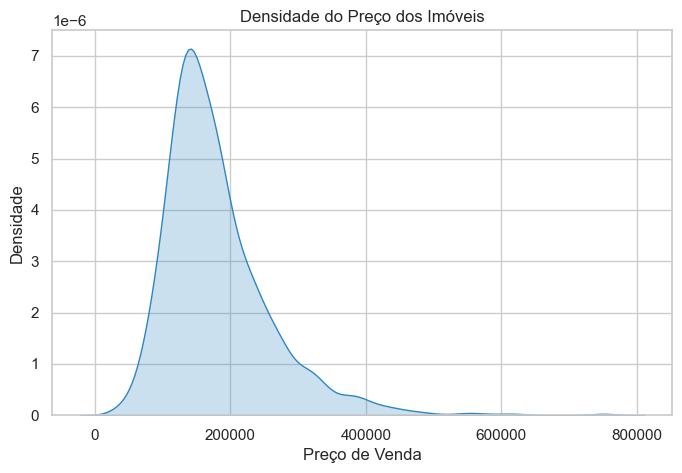

In [16]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=dados,
    x="SalePrice",
    fill=True,
    color="#2E86C1"
)

plt.title("Densidade do Preço dos Imóveis")
plt.xlabel("Preço de Venda")
plt.ylabel("Densidade")

plt.show()

### Interpretação

A curva de densidade confirma o padrão observado no histograma, evidenciando que a maior concentração dos preços de venda está localizada em uma faixa intermediária da distribuição. Observa-se uma distribuição **unimodal**, indicando a existência de um único pico de concentração dos valores, porém com uma **cauda prolongada à direita**, característica típica de distribuições assimétricas.

Esse comportamento mostra que a maioria dos imóveis possui preços relativamente próximos entre si, enquanto um número reduzido de imóveis de alto padrão apresenta valores significativamente superiores, contribuindo para o alongamento da cauda da distribuição.

Do ponto de vista da modelagem estatística, essa assimetria reforça que a variável resposta **SalePrice** não segue uma distribuição aproximadamente normal. Dessa forma, a utilização de modelos capazes de acomodar variáveis contínuas, positivas e assimétricas torna-se mais adequada, justificando posteriormente a escolha do **Modelo Linear Generalizado (MLG)** com distribuição **Gamma**.

In [17]:
fig = px.box(
    dados,
    y="SalePrice",
    color_discrete_sequence=["#2E86C1"]
)

fig.update_layout(
    title="Boxplot do Preço dos Imóveis",
    template="plotly_white"
)

fig.show()

### Interpretação

O boxplot evidencia a presença de diversos valores extremos superiores (outliers), indicando a existência de imóveis com preços significativamente acima da maior parte da amostra. Esses imóveis correspondem, em geral, a residências de alto padrão, que possuem características diferenciadas, como maior área construída, melhor qualidade de acabamento, terrenos mais amplos ou localização privilegiada.

Observa-se que os outliers concentram-se predominantemente na região superior da distribuição, corroborando a assimetria positiva identificada anteriormente no histograma e na curva de densidade. A ausência de valores extremos inferiores relevantes reforça que a maior variabilidade da base está associada aos imóveis de maior valor.

Do ponto de vista do problema de consultoria, esses resultados demonstram que o mercado imobiliário analisado apresenta um segmento de imóveis de alto padrão que se comporta de forma distinta dos demais. Assim, a presença desses valores extremos deve ser considerada durante a modelagem estatística, uma vez que pode influenciar significativamente as estimativas quando se utilizam modelos baseados na normalidade. Essa evidência reforça a escolha de um **Modelo Linear Generalizado (MLG)** com distribuição **Gamma**, mais adequado para representar variáveis contínuas, positivas e assimétricas.

## 5.3.4 Considerações sobre a Distribuição do Preço dos Imóveis

De forma geral, as análises gráficas realizadas evidenciam que a variável **SalePrice** apresenta distribuição contínua, assimétrica à direita e com presença de valores extremos superiores, características frequentemente observadas em dados relacionados ao mercado imobiliário.

Os resultados obtidos indicam que a maior parte dos imóveis concentra-se em uma faixa intermediária de preços, enquanto um número reduzido de imóveis de alto padrão apresenta valores significativamente superiores, contribuindo para o alongamento da cauda da distribuição. Esse comportamento reforça que a distribuição dos preços não é simétrica e sugere que modelos baseados na hipótese de normalidade podem não representar adequadamente os dados.

Essas evidências constituem um importante subsídio para a etapa de modelagem estatística, uma vez que indicam a necessidade de avaliar distribuições mais adequadas para variáveis contínuas, positivas e assimétricas.

Dessa forma, na próxima seção serão realizadas análises complementares, incluindo medidas de assimetria, curtose e testes formais de normalidade, com o objetivo de fundamentar estatisticamente a escolha da família de distribuição mais apropriada para o Modelo Linear Generalizado (MLG).

# 5.4 Avaliação da Distribuição da Variável Resposta

A definição da família de distribuição em um Modelo Linear Generalizado (MLG) deve ser fundamentada nas características da variável resposta. Dessa forma, antes do ajuste dos modelos, torna-se necessário investigar o comportamento da variável **SalePrice**, verificando se sua distribuição é compatível com os pressupostos de diferentes famílias probabilísticas.

Nesta etapa, serão analisadas medidas de assimetria e curtose, além da aplicação de testes formais de normalidade. Essas análises permitirão verificar se a distribuição dos preços apresenta comportamento aproximadamente normal ou se existem evidências que justifiquem a adoção de distribuições mais adequadas para variáveis contínuas, positivas e assimétricas, como a distribuição Gamma.

Os resultados obtidos nessa etapa serão fundamentais para embasar a escolha do modelo estatístico mais apropriado, garantindo que a distribuição adotada represente de forma consistente o comportamento observado nos dados e contribua para a obtenção de estimativas mais confiáveis.

## 5.4.1 Coeficientes de Assimetria e Curtose

Como etapa inicial da avaliação da distribuição da variável resposta, foram calculados os coeficientes de assimetria e curtose da variável **SalePrice**. Essas medidas fornecem informações quantitativas sobre o formato da distribuição, complementando as evidências obtidas por meio das análises gráficas.

O coeficiente de assimetria permite verificar se a distribuição é aproximadamente simétrica ou se apresenta concentração de valores em uma das extremidades. Já o coeficiente de curtose avalia o grau de concentração dos dados em torno da média e o comportamento das caudas da distribuição, possibilitando identificar diferenças em relação ao padrão esperado para uma distribuição normal.

A análise conjunta dessas medidas fornece evidências importantes sobre o comportamento da variável resposta e contribui para verificar se a hipótese de normalidade é plausível ou se distribuições alternativas, como a distribuição Gamma, são mais adequadas para representar os preços dos imóveis. Essas informações serão utilizadas como subsídio para a escolha do Modelo Linear Generalizado (MLG) mais apropriado.

In [21]:
# ==========================================================
# ASSIMETRIA E CURTOSE
# ==========================================================

assimetria = dados["SalePrice"].skew()
curtose = dados["SalePrice"].kurt()

print(f"Assimetria: {assimetria:.4f}")
print(f"Curtose: {curtose:.4f}")

Assimetria: 1.8829
Curtose: 6.5363


### Interpretação

O coeficiente de assimetria foi igual a **1,8829**, indicando uma **assimetria positiva acentuada** na distribuição dos preços dos imóveis. Esse resultado confirma as evidências observadas anteriormente nos histogramas, na curva de densidade e no boxplot, demonstrando que a maior parte dos imóveis concentra-se em faixas intermediárias de preço, enquanto um número reduzido de imóveis de alto padrão apresenta valores significativamente superiores, formando uma cauda longa à direita.

O coeficiente de curtose foi igual a **6,5363**, caracterizando uma distribuição **leptocúrtica**. Esse comportamento indica maior concentração das observações em torno da região central da distribuição e caudas mais pesadas quando comparadas à distribuição normal, evidenciando a presença de valores extremos associados aos imóveis de maior valor.

Do ponto de vista do problema de consultoria, esses resultados mostram que o mercado imobiliário analisado apresenta elevada heterogeneidade, coexistindo imóveis de padrão intermediário e imóveis de alto valor. Essa característica deve ser considerada durante a modelagem estatística, pois distribuições simétricas podem não representar adequadamente esse comportamento.

Assim, os coeficientes de assimetria e curtose reforçam que a variável **SalePrice** não apresenta comportamento compatível com a distribuição normal, fornecendo evidências adicionais para a utilização de um **Modelo Linear Generalizado (MLG)** com distribuição **Gamma**, mais apropriado para modelar variáveis contínuas, positivas e assimétricas.

## 5.4.2 Gráfico Quantil-Quantil (QQ-Plot)

Como complemento às medidas de assimetria e curtose, foi utilizado o gráfico Quantil-Quantil (QQ-Plot) para avaliar visualmente a aderência da variável **SalePrice** à distribuição normal. Esse gráfico compara os quantis observados da variável resposta com os quantis teóricos esperados sob uma distribuição normal.

Quando os pontos permanecem próximos da reta de referência, há evidências de que os dados seguem aproximadamente uma distribuição normal. Por outro lado, desvios sistemáticos em relação à reta indicam que a distribuição observada difere da normalidade.

A utilização do QQ-Plot permite complementar as análises gráficas e estatísticas realizadas anteriormente, fornecendo evidências visuais importantes para avaliar a adequação da hipótese de normalidade e subsidiar a escolha da família de distribuição mais apropriada para o Modelo Linear Generalizado (MLG).

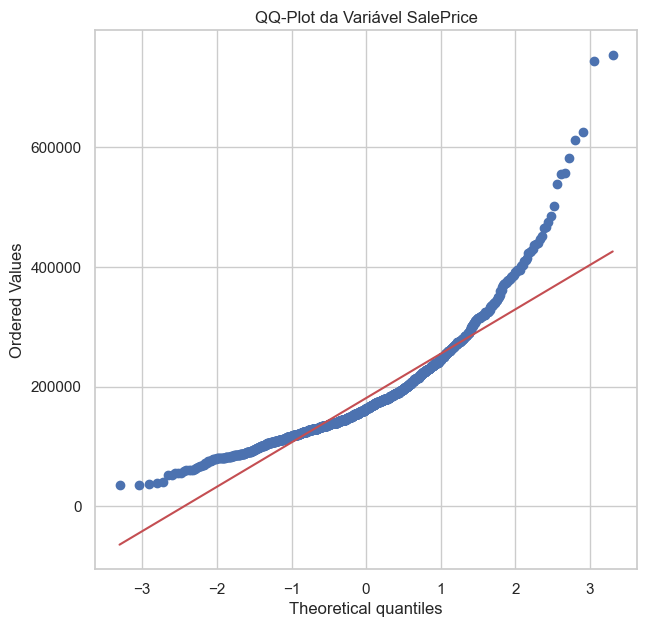

In [22]:
# ==========================================================
# QQ-PLOT
# ==========================================================

plt.figure(figsize=(7,7))

stats.probplot(
    dados["SalePrice"],
    dist="norm",
    plot=plt
)

plt.title("QQ-Plot da Variável SalePrice")

plt.show()

### Interpretação

O gráfico Quantil-Quantil (QQ-Plot) evidencia que os quantis observados não acompanham a reta de referência ao longo de toda a distribuição, principalmente nas extremidades. Observa-se um afastamento considerável dos pontos em relação à reta, sobretudo para os maiores valores de venda, indicando que a variável **SalePrice** não apresenta comportamento compatível com uma distribuição normal.

Esse padrão confirma as evidências obtidas anteriormente por meio dos histogramas, da curva de densidade, do boxplot e dos coeficientes de assimetria e curtose, demonstrando que a distribuição dos preços é assimétrica e influenciada pela presença de imóveis de alto valor.

No contexto do problema de consultoria, esse resultado indica que o mercado imobiliário analisado não apresenta uma distribuição homogênea dos preços, coexistindo imóveis de valor intermediário e um grupo menor de imóveis de alto padrão. Essa característica dificulta a utilização de modelos que assumem normalidade dos dados.

Dessa forma, o QQ-Plot fornece evidências visuais de que a variável **SalePrice** não segue uma distribuição normal, reforçando a necessidade de utilizar um **Modelo Linear Generalizado (MLG)** com distribuição **Gamma**, mais adequado para modelar variáveis contínuas, positivas e com assimetria à direita.

## 5.4.3 Teste de Normalidade

Embora as análises gráficas e os coeficientes de assimetria e curtose tenham fornecido fortes indícios de que a variável **SalePrice** não segue uma distribuição normal, é importante realizar um teste estatístico formal para confirmar essa evidência.

Para esse fim, foi aplicado o **teste de D'Agostino-Pearson**, que avalia simultaneamente os coeficientes de assimetria e curtose, permitindo verificar se a distribuição observada difere significativamente da distribuição normal.

Foram consideradas as seguintes hipóteses:

- **H₀:** os dados seguem uma distribuição normal;
- **H₁:** os dados não seguem uma distribuição normal.

Adotou-se um nível de significância de **5%**. Dessa forma, caso o valor-p seja inferior a **0,05**, rejeita-se a hipótese nula de normalidade, indicando que a variável resposta não apresenta comportamento compatível com uma distribuição normal.

In [23]:
# ==========================================================
# TESTE DE NORMALIDADE
# ==========================================================

estatistica, p_valor = stats.normaltest(dados["SalePrice"])

print(f"Estatística: {estatistica:.4f}")
print(f"p-valor: {p_valor:.6f}")

if p_valor > 0.05:
    print("\nConclusão: Não há evidências para rejeitar a hipótese de normalidade.")
else:
    print("\nConclusão: A hipótese de normalidade foi rejeitada.")

Estatística: 610.8359
p-valor: 0.000000

Conclusão: A hipótese de normalidade foi rejeitada.


### Interpretação

O teste de D'Agostino-Pearson resultou em um **valor-p inferior a 0,05**, levando à rejeição da hipótese nula de normalidade ao nível de significância de 5%. Assim, conclui-se que a variável **SalePrice** não segue uma distribuição normal.

Esse resultado confirma as evidências obtidas nas etapas anteriores, nas quais os histogramas, a curva de densidade, o boxplot, os coeficientes de assimetria e curtose e o gráfico Quantil-Quantil (QQ-Plot) já indicavam uma distribuição assimétrica, com cauda à direita e presença de valores extremos superiores.

Do ponto de vista do problema de consultoria, esse comportamento evidencia que os preços dos imóveis apresentam elevada variabilidade e não se distribuem de forma homogênea, refletindo a coexistência de imóveis de padrão intermediário e de alto padrão na base de dados. Essa característica é típica do mercado imobiliário e deve ser considerada durante a modelagem estatística.

Dessa forma, o teste de normalidade fornece uma confirmação estatística de que a hipótese de normalidade não é adequada para a variável resposta, reforçando a utilização de um **Modelo Linear Generalizado (MLG)** com distribuição **Gamma**, mais apropriado para representar variáveis contínuas, positivas e assimétricas.

## 5.4.4 Considerações sobre a Distribuição da Variável Resposta

A análise conjunta dos resultados gráficos e estatísticos demonstrou que a variável **SalePrice** apresenta distribuição contínua, estritamente positiva, assimétrica à direita e com presença de valores extremos superiores, características frequentemente observadas em dados do mercado imobiliário.

Os histogramas, a curva de densidade, o boxplot e o gráfico Quantil-Quantil (QQ-Plot) evidenciaram desvios em relação à normalidade, resultado posteriormente confirmado pelos coeficientes de assimetria e curtose e pelo teste de D'Agostino-Pearson, que rejeitou a hipótese de distribuição normal ao nível de significância de 5%.

Esses resultados indicam que a utilização de uma distribuição Gaussiana não representa adequadamente o comportamento da variável resposta. Por outro lado, considerando que os preços dos imóveis assumem apenas valores positivos e apresentam assimetria positiva acentuada, a distribuição **Gamma** mostra-se uma alternativa mais apropriada para representar essa variável no contexto dos Modelos Lineares Generalizados (MLG).

Assim, a escolha da distribuição Gamma não se baseia apenas em aspectos teóricos, mas também nas evidências empíricas obtidas ao longo da análise exploratória, garantindo maior coerência entre as características observadas nos dados e a estrutura probabilística adotada pelo modelo.

Na próxima etapa será realizado o ajuste do Modelo Linear Generalizado (MLG), permitindo avaliar o desempenho da distribuição Gamma na modelagem dos preços dos imóveis e verificar sua capacidade de explicar a variabilidade observada na variável resposta.

# 6. Modelagem Estatística

Após a análise exploratória dos dados e a avaliação da distribuição da variável resposta, inicia-se a etapa de modelagem estatística. Nesta fase, busca-se construir um modelo capaz de explicar a variação dos preços dos imóveis a partir de suas principais características estruturais, permitindo compreender quais fatores exercem maior influência sobre o valor de venda.

Antes do ajuste do Modelo Linear Generalizado (MLG), torna-se necessário definir quais variáveis explicativas serão incluídas no modelo. Embora a base de dados contenha **77 variáveis**, a utilização de todas elas não é recomendada, pois pode aumentar a complexidade da modelagem, dificultar a interpretação dos resultados e favorecer problemas como multicolinearidade, além de reduzir a capacidade de generalização do modelo.

Dessa forma, foi realizada uma seleção das variáveis consideradas mais relevantes para a precificação dos imóveis, levando em consideração o problema de consultoria proposto, o conhecimento sobre o mercado imobiliário e as evidências obtidas durante a análise exploratória. Essa etapa tem como objetivo construir um modelo mais parcimonioso, interpretável e capaz de fornecer estimativas confiáveis para o preço de venda dos imóveis.

Nas subseções seguintes serão analisadas as relações entre as variáveis explicativas e a variável resposta (**SalePrice**), fornecendo subsídios para a definição do modelo final e para a identificação dos principais fatores associados à precificação dos imóveis.

## 6.1 Seleção das Variáveis Explicativas

A seleção das variáveis explicativas foi realizada considerando o problema de consultoria proposto, o conhecimento sobre o mercado imobiliário e os resultados obtidos na análise exploratória dos dados. O objetivo foi identificar características estruturais dos imóveis com potencial para explicar a variação observada no preço de venda, contribuindo para a construção de um modelo estatístico consistente e de fácil interpretação.

Foram priorizadas variáveis relacionadas ao tamanho, qualidade da construção, capacidade da garagem, número de quartos, área do terreno, ano de construção e quantidade de banheiros completos, por serem atributos frequentemente associados à valorização de imóveis e amplamente utilizados em estudos de avaliação imobiliária.

A utilização dessas variáveis permite investigar como diferentes características físicas e construtivas influenciam a variável resposta (**SalePrice**), fornecendo subsídios para identificar os fatores mais relevantes na precificação dos imóveis e para desenvolver um modelo capaz de estimar automaticamente o preço de venda de novos imóveis.

In [24]:
# ==========================================================
# SELEÇÃO DAS VARIÁVEIS DO MODELO
# ==========================================================

modelo = dados[
    [
        "SalePrice",
        "GrLivArea",
        "OverallQual",
        "GarageCars",
        "BedroomAbvGr",
        "LotArea",
        "YearBuilt",
        "FullBath",
        "TotRmsAbvGrd"
    ]
]

modelo.head()

,SalePrice,GrLivArea,OverallQual,GarageCars,BedroomAbvGr,LotArea,YearBuilt,FullBath,TotRmsAbvGrd
0,208500,1710,7,2,3,8450,2003,2,8
1,181500,1262,6,2,3,9600,1976,2,6
2,223500,1786,7,2,3,11250,2001,2,6
3,140000,1717,7,3,3,9550,1915,1,7
4,250000,2198,8,3,4,14260,2000,2,9


### Justificativa para a Seleção das Variáveis

As variáveis explicativas foram selecionadas considerando o problema de consultoria proposto, o conhecimento sobre o mercado imobiliário e evidências apresentadas na literatura sobre avaliação de imóveis residenciais.

Foram priorizadas variáveis que representam características estruturais, dimensionais e construtivas dos imóveis, por serem fatores frequentemente utilizados por compradores, vendedores e imobiliárias na definição do valor de mercado. De modo geral, espera-se que imóveis com maior área construída, melhor qualidade de acabamento, maior capacidade de garagem, maior número de cômodos, terrenos mais amplos, construção mais recente e maior quantidade de banheiros apresentem maior valor de venda.

A tabela a seguir apresenta as variáveis selecionadas, que serão utilizadas na construção do Modelo Linear Generalizado (MLG). A escolha dessas variáveis busca equilibrar a capacidade explicativa do modelo e sua interpretabilidade, permitindo identificar quais características exercem maior influência sobre o preço dos imóveis e subsidiando o desenvolvimento do sistema de previsão proposto neste projeto.

In [25]:
# ==========================================================
# JUSTIFICATIVA DAS VARIÁVEIS SELECIONADAS
# ==========================================================

justificativa = pd.DataFrame({
    "Variável": [
        "GrLivArea",
        "OverallQual",
        "GarageCars",
        "BedroomAbvGr",
        "LotArea",
        "YearBuilt",
        "FullBath",
        "TotRmsAbvGrd"
    ],
    "Descrição": [
        "Área construída",
        "Qualidade geral do imóvel",
        "Capacidade da garagem",
        "Número de quartos",
        "Área do terreno",
        "Ano de construção",
        "Número de banheiros completos",
        "Total de cômodos acima do solo"
    ],
    "Justificativa": [
        "Maior área construída tende a elevar o valor do imóvel.",
        "Reflete o padrão construtivo e de acabamento.",
        "Maior capacidade de garagem agrega valor ao imóvel.",
        "Mais dormitórios aumentam a funcionalidade do imóvel.",
        "Terrenos maiores tendem a ser mais valorizados.",
        "Imóveis mais recentes costumam apresentar maior valorização.",
        "Mais banheiros aumentam o conforto dos moradores.",
        "Maior número de cômodos representa imóveis mais amplos."
    ]
})

justificativa

,Variável,Descrição,Justificativa
0,GrLivArea,Área construída,Maior área construída tende a elevar o valor d...
1,OverallQual,Qualidade geral do imóvel,Reflete o padrão construtivo e de acabamento.
2,GarageCars,Capacidade da garagem,Maior capacidade de garagem agrega valor ao im...
3,BedroomAbvGr,Número de quartos,Mais dormitórios aumentam a funcionalidade do ...
4,LotArea,Área do terreno,Terrenos maiores tendem a ser mais valorizados.
5,YearBuilt,Ano de construção,Imóveis mais recentes costumam apresentar maio...
6,FullBath,Número de banheiros completos,Mais banheiros aumentam o conforto dos moradores.
7,TotRmsAbvGrd,Total de cômodos acima do solo,Maior número de cômodos representa imóveis mai...


### Interpretação

A tabela apresenta as variáveis explicativas selecionadas para compor o Modelo Linear Generalizado (MLG), bem como a descrição de cada uma e a justificativa para sua inclusão na modelagem. Todas elas representam características estruturais e construtivas dos imóveis que, segundo a literatura e o conhecimento do mercado imobiliário, podem influenciar o preço de venda.

Observa-se que as variáveis selecionadas respondem diretamente ao problema de consultoria proposto, permitindo investigar como características como **área construída**, **qualidade geral**, **capacidade da garagem**, **número de quartos**, **área do terreno**, **ano de construção**, **quantidade de banheiros completos** e **total de cômodos** estão associadas à variável resposta (**SalePrice**).

Espera-se que imóveis com maior área construída, melhor padrão construtivo, terrenos mais amplos, maior número de banheiros e cômodos, além de construções mais recentes, apresentem preços de venda mais elevados. No entanto, a magnitude e a significância estatística dessas relações serão avaliadas nas etapas seguintes por meio das análises de correlação e do ajuste do Modelo Linear Generalizado.

Dessa forma, essas variáveis constituem um conjunto inicial de preditores para a construção do modelo estatístico, permitindo identificar quais características exercem maior influência sobre o preço dos imóveis e subsidiando o desenvolvimento do sistema de previsão proposto neste projeto.

## 6.2 Análise de Correlação e Multicolinearidade

Após a seleção das variáveis explicativas, torna-se necessário avaliar o grau de associação entre elas antes do ajuste do Modelo Linear Generalizado (MLG). Essa etapa permite verificar se duas ou mais variáveis fornecem informações semelhantes sobre os imóveis, situação que pode comprometer a interpretação dos resultados e a estabilidade das estimativas do modelo.

A presença de elevada correlação entre variáveis explicativas caracteriza a multicolinearidade, fenômeno que pode aumentar a variabilidade dos coeficientes estimados, dificultar a identificação da contribuição individual de cada variável e reduzir a confiabilidade das inferências estatísticas.

Para essa avaliação serão utilizadas a matriz de correlação e o Fator de Inflação da Variância (Variance Inflation Factor – VIF). Enquanto a matriz de correlação permite identificar relações lineares entre os preditores, o VIF quantifica o nível de multicolinearidade existente entre as variáveis selecionadas.

Essa análise é fundamental para garantir que o modelo final seja estável, interpretável e composto por variáveis que contribuam efetivamente para explicar a variação do preço de venda dos imóveis.

### 6.2.1 Matriz de Correlação

Como etapa inicial da avaliação das variáveis explicativas, foi calculada a matriz de correlação de Pearson, permitindo investigar o grau de associação linear entre os preditores selecionados.

Além de identificar possíveis relações entre as variáveis explicativas, a matriz de correlação fornece evidências importantes sobre a existência de multicolinearidade, situação em que duas ou mais variáveis apresentam elevada associação e podem fornecer informações redundantes ao modelo.

A interpretação dessa matriz também auxilia na compreensão das características dos imóveis e de como elas se relacionam entre si, fornecendo subsídios para a construção de um Modelo Linear Generalizado (MLG) mais estável e interpretável. Dessa forma, torna-se possível verificar se as variáveis selecionadas contribuem de maneira complementar para explicar a variação observada no preço de venda dos imóveis.

In [26]:
# ==========================================================
# MATRIZ DE CORRELAÇÃO
# ==========================================================

corr = modelo.drop(columns="SalePrice").corr()

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Matriz de Correlação das Variáveis Explicativas"
)

fig.update_layout(
    width=650,
    height=600,
    template="plotly_white",
    font=dict(size=12),
    title_font_size=18,
    margin=dict(l=40, r=40, t=60, b=40)
)

fig.update_xaxes(tickangle=45)
fig.update_yaxes()

fig.show()

### Interpretação

A matriz de correlação apresenta a intensidade da associação linear entre as variáveis explicativas selecionadas, permitindo avaliar tanto a relação existente entre os preditores quanto possíveis indícios de multicolinearidade antes do ajuste do Modelo Linear Generalizado (MLG).

De modo geral, observa-se que a maioria das correlações apresenta magnitude fraca a moderada, indicando que, embora algumas características dos imóveis estejam relacionadas entre si, cada variável tende a fornecer informações complementares sobre a precificação dos imóveis.

As maiores correlações foram observadas entre **GrLivArea** e **TotRmsAbvGrd** (0,83), sugerindo que imóveis com maior área construída tendem a possuir maior número de cômodos acima do nível do solo. Também se destacam as associações entre **BedroomAbvGr** e **TotRmsAbvGrd** (0,68), **GrLivArea** e **FullBath** (0,63) e **OverallQual** e **GarageCars** (0,60). Esses resultados são coerentes com o contexto do mercado imobiliário, uma vez que imóveis maiores geralmente apresentam mais cômodos, maior número de banheiros e melhor infraestrutura.

Do ponto de vista do problema de consultoria, essas relações indicam que algumas características estruturais evoluem conjuntamente, refletindo diferentes aspectos da qualidade e do porte dos imóveis. Entretanto, nenhuma das correlações observadas se aproxima de uma associação perfeita (±1), sugerindo que as variáveis ainda fornecem informações distintas e potencialmente relevantes para explicar a variação do preço de venda (**SalePrice**).

Apesar desses resultados serem favoráveis, a confirmação da ausência de multicolinearidade será realizada por meio do cálculo do **Fator de Inflação da Variância (VIF)**, permitindo verificar se as correlações observadas comprometem ou não a estabilidade e a interpretação dos coeficientes do modelo estatístico.

### 6.2.2 Fator de Inflação da Variância (VIF)

Como complemento à matriz de correlação, foi calculado o **Fator de Inflação da Variância (Variance Inflation Factor – VIF)** para avaliar quantitativamente a presença de multicolinearidade entre as variáveis explicativas selecionadas.

Embora a matriz de correlação permita identificar associações lineares entre pares de variáveis, o VIF fornece uma medida mais abrangente, indicando quanto a variância dos coeficientes estimados pode ser inflacionada em decorrência da correlação existente entre os preditores.

Em geral, valores de **VIF inferiores a 5** indicam baixa multicolinearidade, sugerindo que as variáveis fornecem informações complementares para o modelo. Por outro lado, valores elevados podem indicar redundância entre os preditores, dificultando a interpretação dos coeficientes e reduzindo a estabilidade das estimativas.

A avaliação do VIF é uma etapa importante para garantir que o Modelo Linear Generalizado (MLG) seja construído com variáveis que contribuam efetivamente para explicar a variação do preço de venda dos imóveis, sem comprometer a confiabilidade dos resultados.

In [27]:
# ==========================================================
# FATOR DE INFLAÇÃO DA VARIÂNCIA (VIF)
# ==========================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

X = modelo.drop(columns="SalePrice")

X = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variável"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif.round(2)

,Variável,VIF
0,const,8130.38
1,GrLivArea,4.60
2,OverallQual,2.56
3,GarageCars,1.87
4,BedroomAbvGr,2.06
5,LotArea,1.09
6,YearBuilt,2.03
7,FullBath,2.17
8,TotRmsAbvGrd,4.33


### Interpretação

O Fator de Inflação da Variância (VIF) foi utilizado para avaliar a presença de multicolinearidade entre as variáveis explicativas selecionadas, verificando se existiam preditores com informações excessivamente redundantes que pudessem comprometer a interpretação do Modelo Linear Generalizado (MLG).

Observa-se que todas as variáveis apresentaram **valores de VIF inferiores a 5**, indicando ausência de multicolinearidade severa. Esse resultado sugere que cada variável contribui com informações próprias para explicar a variação observada no preço de venda dos imóveis, sem causar instabilidade significativa nas estimativas dos coeficientes.

Os maiores valores de VIF foram observados para **GrLivArea** (VIF = 4,60) e **TotRmsAbvGrd** (VIF = 4,33). Esse comportamento era esperado, uma vez que imóveis com maior área construída tendem a apresentar maior número de cômodos acima do nível do solo. Apesar dessa associação, os valores permanecem abaixo do limite geralmente recomendado na literatura, não caracterizando um problema de multicolinearidade.

Do ponto de vista do problema de consultoria, esse resultado demonstra que o conjunto de variáveis selecionado é adequado para representar diferentes características dos imóveis, permitindo identificar a contribuição individual de cada fator na precificação. Assim, conclui-se que todas as variáveis podem ser mantidas no Modelo Linear Generalizado (MLG), não havendo necessidade de exclusão de preditores por problemas de multicolinearidade.

### Considerações da Etapa

A análise conjunta da matriz de correlação e do Fator de Inflação da Variância (VIF) demonstrou que o conjunto de variáveis explicativas selecionado apresenta níveis aceitáveis de associação linear, não sendo observadas evidências de multicolinearidade capaz de comprometer a interpretação ou a estabilidade do Modelo Linear Generalizado (MLG).

Esses resultados indicam que cada variável contribui com informações relevantes sobre diferentes características dos imóveis, permitindo avaliar de forma individual sua influência sobre a variável resposta (**SalePrice**). Dessa forma, o conjunto de preditores selecionado mostra-se adequado para representar os fatores associados à precificação dos imóveis.

Com base nessas evidências, todas as variáveis serão mantidas na etapa de modelagem estatística. Na seção seguinte será realizado o ajuste do Modelo Linear Generalizado (MLG), permitindo identificar quais características exercem influência estatisticamente significativa sobre o preço de venda dos imóveis e construir o modelo que dará origem ao sistema de previsão desenvolvido neste projeto.

## 6.3 Ajuste do Modelo Linear Generalizado (MLG)

Após a seleção das variáveis explicativas e a verificação da ausência de multicolinearidade significativa, realizou-se o ajuste dos Modelos Lineares Generalizados (MLG) com o objetivo de modelar o preço de venda dos imóveis a partir de suas principais características estruturais.

A escolha do modelo estatístico constitui uma etapa fundamental do projeto de consultoria, uma vez que a qualidade das estimativas depende da adequação da distribuição probabilística às características observadas na variável resposta.

Conforme evidenciado nas análises exploratórias, a variável **SalePrice** apresenta valores contínuos, estritamente positivos e distribuição assimétrica à direita. Entretanto, para verificar empiricamente qual estrutura representa melhor os dados, foram ajustados e comparados dois modelos:

- **Modelo Linear Generalizado com distribuição Gaussiana**;
- **Modelo Linear Generalizado com distribuição Gamma e função de ligação log**.

A comparação entre os modelos permitirá identificar aquele que apresenta melhor desempenho estatístico e maior capacidade de representar o comportamento dos preços dos imóveis. O modelo selecionado será posteriormente incorporado ao sistema de previsão desenvolvido em Streamlit, constituindo o produto final deste projeto de consultoria estatística.

In [28]:
# ==========================================================
# DEFINIÇÃO DA FÓRMULA DO MODELO
# ==========================================================

formula = """
SalePrice ~ GrLivArea + OverallQual + GarageCars + BedroomAbvGr
+ LotArea + YearBuilt + FullBath + TotRmsAbvGrd
"""

In [29]:
# ==========================================================
# MLG GAUSSIANO
# ==========================================================

modelo_gaussiano = smf.glm(
    formula=formula,
    data=modelo,
    family=sm.families.Gaussian()
).fit()

print(modelo_gaussiano.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              SalePrice   No. Observations:                 1460
Model:                            GLM   Df Residuals:                     1451
Model Family:                Gaussian   Df Model:                            8
Link Function:               Identity   Scale:                      1.4675e+09
Method:                          IRLS   Log-Likelihood:                -17475.
Date:                Fri, 03 Jul 2026   Deviance:                   2.1293e+12
Time:                        08:36:42   Pearson chi2:                 2.13e+12
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9633
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     -8.71e+05   9.04e+04     -9.635   

### Interpretação

O Modelo Linear Generalizado (MLG) com distribuição **Gaussiana** e função de ligação identidade foi ajustado utilizando as características estruturais dos imóveis previamente selecionadas.

Os resultados mostram que **todas as variáveis apresentaram significância estatística ao nível de 5% (p < 0,05)**, indicando que cada uma contribui de forma significativa para explicar a variação observada no preço de venda dos imóveis (**SalePrice**).

Entre as variáveis analisadas, **OverallQual** destacou-se como uma das mais influentes na precificação dos imóveis. O coeficiente estimado indica que, mantendo as demais características constantes, o aumento de uma unidade na qualidade geral do imóvel está associado a um acréscimo médio de aproximadamente **US$ 22.060** no preço de venda. Esse resultado evidencia que o padrão construtivo e o acabamento exercem forte influência sobre a valorização dos imóveis.

A variável **GarageCars** também apresentou efeito positivo expressivo, indicando que imóveis com maior capacidade de garagem tendem a apresentar um aumento médio de aproximadamente **US$ 13.840** no preço de venda. De forma semelhante, observou-se efeito positivo para **GrLivArea**, sugerindo que cada unidade adicional de área construída está associada a um aumento médio de cerca de **US$ 60** no preço esperado do imóvel.

As variáveis **LotArea**, **YearBuilt** e **TotRmsAbvGrd** também apresentaram coeficientes positivos e estatisticamente significativos, indicando que terrenos maiores, imóveis mais recentes e maior número de cômodos estão associados à valorização dos imóveis.

Por outro lado, **BedroomAbvGr** e **FullBath** apresentaram coeficientes negativos. Esse resultado não deve ser interpretado de forma isolada, pois os coeficientes representam o efeito de cada variável mantendo todas as demais constantes. Como essas variáveis estão correlacionadas com características como área construída e número total de cômodos, seus efeitos refletem a contribuição adicional dessas características dentro do conjunto de variáveis do modelo.

Do ponto de vista do problema de consultoria, os resultados demonstram que fatores relacionados à **qualidade da construção**, **área construída**, **capacidade da garagem**, **tamanho do terreno** e **idade do imóvel** exercem influência significativa sobre o preço de venda. Essas evidências permitem compreender quais atributos agregam maior valor aos imóveis e fornecem uma base objetiva para a construção de um sistema automatizado de estimativa de preços.

Embora o modelo Gaussiano tenha apresentado bom desempenho inicial, sua adequação será comparada com o Modelo Linear Generalizado utilizando distribuição **Gamma**, cuja estrutura probabilística é mais compatível com as características observadas na variável resposta. A comparação entre os modelos permitirá selecionar a alternativa mais apropriada para compor o produto final deste projeto.

In [30]:
# ==========================================================
# MLG GAMMA COM LINK LOG
# ==========================================================

modelo_gamma = smf.glm(
    formula=formula,
    data=modelo,
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

print(modelo_gamma.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              SalePrice   No. Observations:                 1460
Model:                            GLM   Df Residuals:                     1451
Model Family:                   Gamma   Df Model:                            8
Link Function:                    Log   Scale:                        0.024943
Method:                          IRLS   Log-Likelihood:                -17015.
Date:                Fri, 03 Jul 2026   Deviance:                       40.413
Time:                        08:36:50   Pearson chi2:                     36.2
No. Iterations:                    16   Pseudo R-squ. (CS):             0.9957
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        5.1791      0.373     13.896   

### Interpretação

O Modelo Linear Generalizado (MLG) com distribuição **Gamma** e função de ligação **log** foi ajustado utilizando as características estruturais dos imóveis previamente selecionadas, considerando uma estrutura probabilística mais compatível com a variável resposta, que apresenta valores contínuos, estritamente positivos e distribuição assimétrica à direita.

Os resultados indicam que a maior parte das variáveis apresentou **significância estatística ao nível de 5% (p < 0,05)**, evidenciando que essas características exercem influência significativa sobre o preço de venda dos imóveis (**SalePrice**).

As variáveis **GrLivArea** (área construída), **OverallQual** (qualidade geral do imóvel), **GarageCars** (capacidade da garagem), **LotArea** (área do terreno), **YearBuilt** (ano de construção), **BedroomAbvGr** (número de quartos) e **FullBath** (número de banheiros completos) apresentaram coeficientes estatisticamente significativos, indicando que essas características contribuem para explicar a variação observada no preço dos imóveis.

Entre elas, destacam-se principalmente **OverallQual**, **GrLivArea** e **GarageCars**, reforçando que o padrão construtivo, o tamanho do imóvel e a infraestrutura disponível constituem alguns dos fatores mais relevantes para a valorização dos imóveis. Esse resultado está de acordo com o comportamento esperado para o mercado imobiliário e corrobora as evidências observadas durante a análise exploratória dos dados.

Por outro lado, a variável **TotRmsAbvGrd** (número total de cômodos acima do nível do solo) não apresentou significância estatística (**p = 0,636**). Esse resultado sugere que, após considerar simultaneamente as demais características do imóvel, essa variável não acrescenta informação suficiente para explicar o preço de venda, possivelmente por compartilhar parte de sua informação com outras variáveis relacionadas ao tamanho do imóvel, como a área construída (**GrLivArea**).

Do ponto de vista do problema de consultoria, os resultados demonstram que fatores relacionados à qualidade da construção, dimensão do imóvel, capacidade da garagem, tamanho do terreno, idade da construção e quantidade de banheiros exercem influência significativa sobre a precificação dos imóveis. Essas evidências permitem identificar quais atributos agregam maior valor ao imóvel e fornecem uma base estatística consistente para a construção de um sistema automatizado de estimativa de preços.

Além disso, a utilização da distribuição **Gamma** mostra-se coerente com as características observadas na variável resposta, proporcionando uma modelagem mais adequada para dados contínuos, positivos e assimétricos. Nas próximas etapas, esse modelo será comparado ao modelo Gaussiano por meio de medidas de desempenho, permitindo selecionar a alternativa que apresentará melhor capacidade preditiva e que será incorporada ao sistema desenvolvido em Streamlit.

## 6.4 Comparação dos Modelos

Após o ajuste dos Modelos Lineares Generalizados (MLG) com distribuições **Gaussiana** e **Gamma**, realizou-se uma comparação entre seus indicadores de ajuste, com o objetivo de identificar qual estrutura probabilística representa de forma mais adequada o comportamento dos preços dos imóveis.

A comparação entre modelos constitui uma etapa essencial da modelagem estatística, pois permite selecionar a alternativa que apresenta melhor equilíbrio entre qualidade do ajuste, capacidade preditiva e parcimônia. Dessa forma, a escolha do modelo final não se baseia apenas em aspectos teóricos, mas também em evidências obtidas a partir dos próprios dados.

Para essa avaliação foram considerados o **Log-Likelihood**, a **Deviance** e o **Critério de Informação de Akaike (AIC)**. Em geral, modelos com maior Log-Likelihood e menores valores de Deviance e AIC apresentam melhor desempenho, indicando maior aderência aos dados observados.

Os resultados dessa comparação fornecerão subsídios para a escolha do modelo que será utilizado na construção do sistema de previsão de preços de imóveis desenvolvido neste projeto.

In [31]:
# ==========================================================
# COMPARAÇÃO DOS MODELOS
# ==========================================================

comparacao = pd.DataFrame({
    "Modelo": ["Gaussiano", "Gamma"],
    "AIC": [
        modelo_gaussiano.aic,
        modelo_gamma.aic
    ],
    "Log-Likelihood": [
        modelo_gaussiano.llf,
        modelo_gamma.llf
    ],
    "Deviance": [
        modelo_gaussiano.deviance,
        modelo_gamma.deviance
    ]
})

comparacao.round(2)

,Modelo,AIC,Log-Likelihood,Deviance
0,Gaussiano,34968.19,-17475.10,2.129275e+12
1,Gamma,34048.71,-17015.35,4.041000e+01


### Interpretação

A comparação entre os Modelos Lineares Generalizados (MLG) permitiu identificar qual distribuição probabilística apresentou melhor desempenho para representar o comportamento dos preços de venda dos imóveis.

Observa-se que o modelo com distribuição **Gamma** apresentou menor valor do **Critério de Informação de Akaike (AIC = 34048,71)** quando comparado ao modelo **Gaussiano (AIC = 34968,19)**. Como menores valores de AIC indicam melhor equilíbrio entre qualidade de ajuste e complexidade do modelo, esse resultado favorece a utilização da distribuição Gamma.

Além disso, o modelo Gamma apresentou **maior Log-Likelihood (-17015,35)** em relação ao modelo Gaussiano (-17475,10), indicando melhor aderência aos dados observados e maior capacidade de representar a variabilidade presente na variável resposta.

Outro aspecto importante refere-se à **Deviance**, que apresentou valor significativamente inferior no modelo Gamma (**40,41**) em comparação ao modelo Gaussiano (**2,13 × 10¹²**). Esse resultado evidencia que a distribuição Gamma proporciona um ajuste muito mais adequado aos dados, reduzindo substancialmente o erro de modelagem.

Esses resultados são consistentes com as análises exploratórias realizadas anteriormente, que evidenciaram que a variável **SalePrice** é contínua, estritamente positiva e apresenta assimetria à direita. Dessa forma, além de apresentar melhor desempenho estatístico, a distribuição **Gamma** também é teoricamente mais compatível com as características observadas na variável resposta.

Do ponto de vista do problema de consultoria, a escolha do modelo Gamma garante estimativas mais confiáveis para o preço de venda dos imóveis, aumentando a precisão das previsões e proporcionando maior segurança para sua utilização em processos de avaliação imobiliária.

Assim, considerando conjuntamente os indicadores de ajuste, as características da variável resposta e o objetivo do projeto, o **Modelo Linear Generalizado com distribuição Gamma e função de ligação log** foi selecionado como o modelo final e será utilizado na construção do sistema de previsão de preços de imóveis desenvolvido em Streamlit, constituindo o principal produto deste projeto de consultoria estatística.

## 6.5 Refinamento do Modelo

Após a comparação entre os modelos, verificou-se que o Modelo Linear Generalizado (MLG) com distribuição **Gamma** apresentou o melhor desempenho para representar o preço de venda dos imóveis. A partir dessa escolha, foi realizada uma etapa de refinamento do modelo, com o objetivo de obter uma especificação mais parcimoniosa e composta apenas por variáveis que contribuíssem significativamente para explicar a variável resposta.

Inicialmente, foi avaliada a significância estatística de cada variável explicativa por meio dos respectivos **p-valores**. Essa análise permite identificar quais preditores apresentam contribuição efetiva para a modelagem do preço dos imóveis, possibilitando a remoção de variáveis que não acrescentam informação relevante ao modelo.

Observou-se que a variável **TotRmsAbvGrd** (número total de cômodos acima do nível do solo) não apresentou significância estatística ao nível de 5% (**p = 0,636**). Esse resultado indica que, após considerar simultaneamente as demais características estruturais do imóvel, essa variável não exerce influência estatisticamente significativa sobre o preço de venda.

Dessa forma, optou-se pela remoção dessa variável e pelo ajuste de um novo Modelo Linear Generalizado com distribuição Gamma. Esse procedimento busca obter um modelo mais simples, interpretável e eficiente, preservando apenas as variáveis que apresentam contribuição estatisticamente significativa para explicar a variação observada no preço dos imóveis.

In [32]:
# ==========================================================
# MODELO GAMMA REFINADO
# ==========================================================

formula_refinada = """
SalePrice ~ GrLivArea + OverallQual + GarageCars +
BedroomAbvGr + LotArea + YearBuilt + FullBath
"""

modelo_gamma_final = smf.glm(
    formula=formula_refinada,
    data=modelo,
    family=sm.families.Gamma(
        link=sm.families.links.Log()
    )
).fit()

print(modelo_gamma_final.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              SalePrice   No. Observations:                 1460
Model:                            GLM   Df Residuals:                     1452
Model Family:                   Gamma   Df Model:                            7
Link Function:                    Log   Scale:                        0.024928
Method:                          IRLS   Log-Likelihood:                -17016.
Date:                Fri, 03 Jul 2026   Deviance:                       40.418
Time:                        08:37:03   Pearson chi2:                     36.2
No. Iterations:                    16   Pseudo R-squ. (CS):             0.9957
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        5.1970      0.370     14.035   

In [33]:
# ==========================================================
# COMPARAÇÃO ENTRE OS MODELOS GAMMA
# ==========================================================

comparacao_gamma = pd.DataFrame({

    "Modelo":[
        "Gamma Inicial",
        "Gamma Refinado"
    ],

    "AIC":[
        modelo_gamma.aic,
        modelo_gamma_final.aic
    ],

    "LogLik":[
        modelo_gamma.llf,
        modelo_gamma_final.llf
    ],

    "Deviance":[
        modelo_gamma.deviance,
        modelo_gamma_final.deviance
    ]

})

comparacao_gamma.round(2)

,Modelo,AIC,LogLik,Deviance
0,Gamma Inicial,34048.71,-17015.35,40.41
1,Gamma Refinado,34047.02,-17015.51,40.42


### Interpretação

Após a remoção da variável **TotRmsAbvGrd**, foi ajustado um novo Modelo Linear Generalizado (MLG) com distribuição **Gamma** e função de ligação **log**, mantendo apenas as variáveis que apresentaram contribuição estatisticamente significativa para explicar o preço de venda dos imóveis.

A comparação entre o modelo Gamma inicial e o modelo refinado mostrou que o modelo refinado apresentou **menor valor do Critério de Informação de Akaike (AIC = 34047,02)** em relação ao modelo inicial (**AIC = 34048,71**). Embora a redução seja pequena, esse resultado indica uma melhora no equilíbrio entre qualidade de ajuste e complexidade do modelo, favorecendo a escolha da versão mais parcimoniosa.

Além disso, a **Deviance** permaneceu praticamente inalterada (**40,42** no modelo refinado contra **40,41** no modelo inicial), demonstrando que a remoção da variável **TotRmsAbvGrd** não comprometeu a capacidade explicativa do modelo. Isso evidencia que essa variável fornecia pouca informação adicional quando analisada em conjunto com as demais características estruturais do imóvel.

Outro aspecto importante é que **todas as variáveis remanescentes apresentaram significância estatística ao nível de 5% (p < 0,05)**, indicando que cada uma delas contribui de forma efetiva para explicar a variação observada na variável resposta (**SalePrice**).

Do ponto de vista do problema de consultoria, o modelo refinado apresenta uma estrutura mais simples, interpretável e eficiente, permitindo identificar os principais fatores associados à precificação dos imóveis sem perda significativa da qualidade do ajuste. Essa característica torna o modelo mais adequado para aplicações práticas, como sistemas automatizados de avaliação imobiliária.

Dessa forma, o **Modelo Linear Generalizado com distribuição Gamma e função de ligação log**, em sua versão refinada, foi adotado como **modelo final** deste projeto. Esse modelo será incorporado ao sistema desenvolvido em **Streamlit**, constituindo o principal produto da consultoria e permitindo estimar automaticamente o preço de venda de novos imóveis a partir de suas características estruturais.

## 6.6 Diagnóstico do Modelo

Após a definição do Modelo Linear Generalizado (MLG) com distribuição **Gamma** e função de ligação **log** como modelo final, realizou-se a etapa de diagnóstico com o objetivo de avaliar a qualidade do ajuste e verificar se os pressupostos da modelagem foram adequadamente atendidos.

A análise dos resíduos constitui uma etapa fundamental da validação do modelo, pois permite identificar possíveis padrões não explicados, desvios em relação ao comportamento esperado e observações atípicas que possam comprometer a confiabilidade das estimativas.

Para essa avaliação foram utilizados gráficos diagnósticos dos resíduos, permitindo verificar a adequação do modelo aos dados observados e identificar possíveis evidências de falta de ajuste.

Essa etapa é essencial para confirmar que o Modelo Linear Generalizado selecionado fornece uma representação estatisticamente adequada do comportamento dos preços dos imóveis, garantindo maior confiabilidade às estimativas que serão utilizadas no sistema de previsão desenvolvido neste projeto.

### 6.6.1 Resíduos versus Valores Ajustados

O gráfico de resíduos versus valores ajustados foi utilizado para avaliar a adequação do Modelo Linear Generalizado (MLG), verificando se os resíduos apresentam comportamento aleatório em torno de zero ao longo de toda a faixa de valores previstos.

Esse gráfico permite identificar possíveis padrões sistemáticos, heterogeneidade da variância, tendências não capturadas pelo modelo ou indícios de especificação inadequada. Em um modelo bem ajustado, espera-se que os resíduos estejam distribuídos de forma aleatória, sem apresentar estruturas definidas ou variações sistemáticas em função dos valores ajustados.

A análise desse gráfico fornece evidências importantes sobre a qualidade do ajuste do modelo e sua capacidade de representar adequadamente a relação entre as características estruturais dos imóveis e o preço de venda.

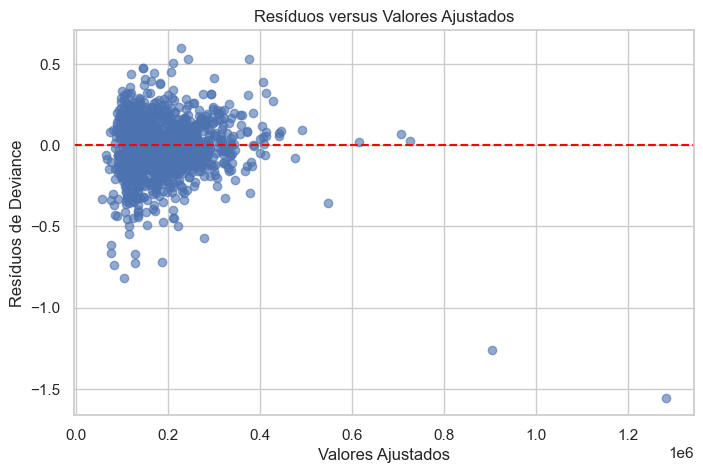

In [34]:
# ==========================================================
# RESÍDUOS VS VALORES AJUSTADOS
# ==========================================================

residuos = modelo_gamma_final.resid_deviance
ajustados = modelo_gamma_final.fittedvalues

plt.figure(figsize=(8,5))

plt.scatter(
    ajustados,
    residuos,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Valores Ajustados")
plt.ylabel("Resíduos de Deviance")
plt.title("Resíduos versus Valores Ajustados")

plt.show()

### Interpretação

O gráfico de resíduos versus valores ajustados mostra que os resíduos estão distribuídos de forma aproximadamente aleatória em torno da linha horizontal correspondente ao valor zero, sem evidências de padrões sistemáticos ou tendências que indiquem inadequação do modelo.

Observa-se maior concentração de observações para imóveis com preços baixos e intermediários, enquanto alguns imóveis de maior valor apresentam resíduos mais dispersos. Esse comportamento é esperado em bases de dados do mercado imobiliário, uma vez que imóveis de alto padrão tendem a apresentar maior variabilidade de preços e características mais heterogêneas.

Embora existam algumas observações mais afastadas da região central, elas ocorrem de forma pontual e não configuram um padrão capaz de comprometer a qualidade do ajuste. Assim, os resíduos sugerem que o Modelo Linear Generalizado com distribuição Gamma representa adequadamente a relação entre as características estruturais dos imóveis e o preço de venda.

Do ponto de vista da consultoria, esse resultado reforça a confiabilidade do modelo para estimar o preço de novos imóveis, fornecendo uma base estatística consistente para o sistema de previsão desenvolvido neste projeto.

### 6.6.2 Distribuição dos Resíduos

O histograma dos resíduos permite avaliar sua distribuição e verificar possíveis assimetrias ou concentração excessiva em determinadas regiões.

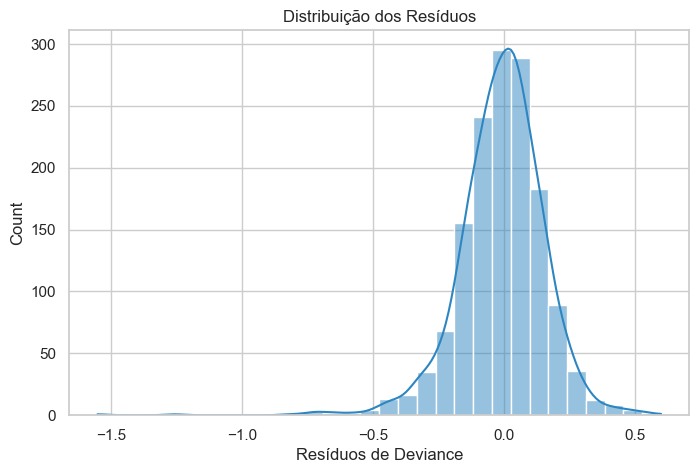

In [35]:
# ==========================================================
# HISTOGRAMA DOS RESÍDUOS
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    residuos,
    bins=30,
    kde=True,
    color="#2E86C1"
)

plt.title("Distribuição dos Resíduos")

plt.xlabel("Resíduos de Deviance")

plt.show()

### Interpretação

O histograma dos resíduos apresenta distribuição aproximadamente centrada em torno de zero, indicando que o modelo não apresenta viés sistemático nas previsões, ou seja, não tende a superestimar ou subestimar os preços dos imóveis de forma consistente.

Observa-se que a maior parte dos resíduos concentra-se próxima ao valor zero, sugerindo que, para a maioria das observações, os valores previstos encontram-se próximos dos valores efetivamente observados. Embora seja possível identificar uma leve assimetria negativa decorrente da presença de alguns resíduos extremos, esse comportamento é pontual e não compromete a qualidade geral do ajuste.

De forma geral, o histograma indica que os resíduos apresentam comportamento compatível com um modelo bem ajustado, reforçando que o Modelo Linear Generalizado com distribuição Gamma representa adequadamente os dados utilizados na análise.

Do ponto de vista do problema de consultoria, esse resultado aumenta a confiabilidade das previsões geradas pelo modelo, tornando-o apropriado para compor o sistema de estimativa de preços de imóveis desenvolvido neste projeto.

### 6.6.3 QQ-Plot dos Resíduos

O gráfico Quantil-Quantil foi utilizado para avaliar o comportamento dos resíduos em relação à distribuição teórica esperada.

Embora a normalidade dos resíduos não seja um requisito estrito para Modelos Lineares Generalizados, esse gráfico auxilia na identificação de possíveis desvios importantes.

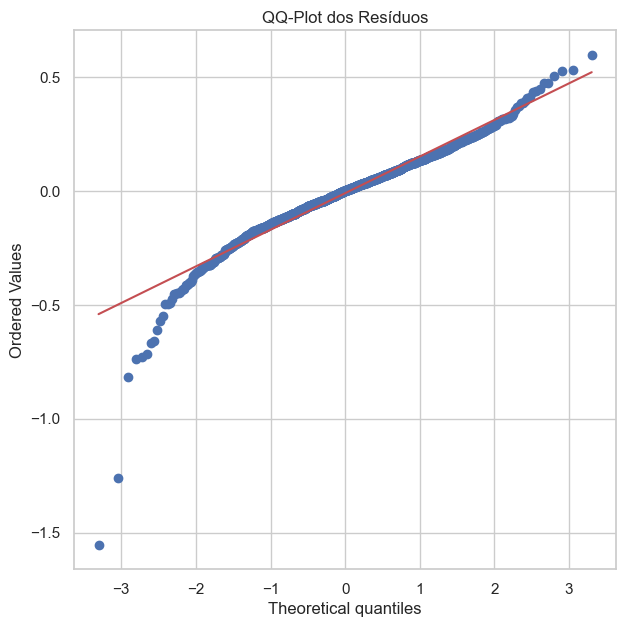

In [36]:
# ==========================================================
# QQ-PLOT DOS RESÍDUOS
# ==========================================================

plt.figure(figsize=(7,7))

stats.probplot(
    residuos,
    dist="norm",
    plot=plt
)

plt.title("QQ-Plot dos Resíduos")

plt.show()

### Interpretação

O gráfico Quantil-Quantil (QQ-Plot) mostra que a maior parte dos resíduos acompanha satisfatoriamente a reta de referência, especialmente na região central da distribuição. Esse comportamento indica que os resíduos apresentam distribuição compatível com a esperada para um modelo bem ajustado.

Observam-se pequenos desvios nas extremidades da reta, principalmente associados a imóveis com preços mais elevados. Esse comportamento é comum em bases de dados imobiliárias, nas quais imóveis de alto padrão costumam apresentar maior variabilidade e características mais heterogêneas quando comparados aos demais imóveis da amostra.

Apesar desses desvios, não são observadas discrepâncias suficientemente expressivas para comprometer a qualidade geral do ajuste. Assim, o QQ-Plot fornece evidências de que o Modelo Linear Generalizado com distribuição Gamma apresenta comportamento compatível com os dados observados, reforçando sua adequação para representar o preço de venda dos imóveis.

Do ponto de vista do problema de consultoria, esse resultado aumenta a confiança na utilização do modelo para realizar estimativas de preços de novos imóveis, contribuindo para o desenvolvimento de um sistema de previsão estatisticamente consistente e aplicável ao contexto do mercado imobiliário.

### 6.6.4 Medidas de Desempenho

Por fim, foram calculadas métricas de desempenho para quantificar a capacidade preditiva do modelo ajustado.

In [37]:
# ==========================================================
# MÉTRICAS DO MODELO
# ==========================================================

y_real = modelo["SalePrice"]

y_pred = modelo_gamma_final.fittedvalues

rmse = np.sqrt(mean_squared_error(y_real, y_pred))
mae = mean_absolute_error(y_real, y_pred)
r2 = r2_score(y_real, y_pred)

metricas = pd.DataFrame({

    "Métrica":[
        "RMSE",
        "MAE",
        "R²"
    ],

    "Valor":[
        rmse,
        mae,
        r2
    ]

})

metricas.round(4)

,Métrica,Valor
0,RMSE,45610.5552
1,MAE,21879.6439
2,R²,0.6701


### Interpretação

As métricas de desempenho indicam que o Modelo Linear Generalizado (MLG) com distribuição Gamma apresenta capacidade satisfatória para estimar o preço de venda dos imóveis, evidenciando bom desempenho para fins de modelagem e previsão.

O **Erro Médio Absoluto (MAE = 21.879,64)** indica que, em média, as estimativas produzidas pelo modelo diferem do valor observado em aproximadamente **US$ 21.880**. Essa métrica fornece uma medida direta da precisão das previsões e demonstra que o modelo apresenta erros médios relativamente reduzidos quando comparados à amplitude dos preços observados na base de dados.

O **RMSE (45.610,56)** apresentou valor superior ao MAE, comportamento esperado por atribuir maior peso aos erros de maior magnitude. Esse resultado sugere que o modelo apresenta algumas previsões com erros mais elevados, principalmente para imóveis de alto padrão, cuja precificação costuma apresentar maior variabilidade.

O coeficiente de determinação (**R² = 0,6701**) indica que aproximadamente **67% da variabilidade observada nos preços de venda dos imóveis é explicada pelas variáveis incluídas no modelo**. Esse resultado evidencia que fatores como área construída, qualidade do imóvel, capacidade da garagem, área do terreno, ano de construção, número de quartos e quantidade de banheiros representam importantes determinantes da precificação imobiliária.

Do ponto de vista do problema de consultoria, essas métricas demonstram que o modelo possui capacidade preditiva satisfatória para estimar o preço de novos imóveis, fornecendo resultados consistentes para apoiar processos de avaliação imobiliária e tomada de decisão.

Assim, o Modelo Linear Generalizado com distribuição Gamma apresentou desempenho adequado para compor o sistema de previsão desenvolvido em Streamlit, constituindo o modelo estatístico adotado como solução final deste projeto.

## 6.7 Considerações sobre o Modelo Final

As análises realizadas ao longo desta etapa permitiram identificar o **Modelo Linear Generalizado (MLG) com distribuição Gamma e função de ligação log** como a alternativa mais adequada para explicar o preço de venda dos imóveis.

A escolha desse modelo foi fundamentada tanto em aspectos teóricos quanto empíricos. Do ponto de vista estatístico, a variável resposta (**SalePrice**) apresentou valores estritamente positivos, distribuição assimétrica à direita e rejeição da hipótese de normalidade, características compatíveis com a utilização da distribuição Gamma. Além disso, a comparação entre os modelos evidenciou melhor desempenho da distribuição Gamma em relação ao modelo Gaussiano, apresentando menores valores de AIC e Deviance.

O refinamento da modelagem resultou em um modelo mais parcimonioso, composto apenas por variáveis estatisticamente significativas. As análises mostraram que características como **área construída**, **qualidade geral do imóvel**, **capacidade da garagem**, **área do terreno**, **ano de construção**, **número de quartos** e **quantidade de banheiros completos** exercem influência significativa sobre o preço de venda dos imóveis, evidenciando quais fatores são mais relevantes para a precificação imobiliária.

As análises de diagnóstico indicaram comportamento adequado dos resíduos, sem evidências de problemas que comprometessem a validade do modelo. Além disso, as métricas de desempenho demonstraram capacidade preditiva satisfatória, reforçando a confiabilidade das estimativas produzidas.

Do ponto de vista do problema de consultoria, o modelo desenvolvido atende ao objetivo proposto, permitindo estimar o preço de venda de imóveis a partir de suas características estruturais e identificar os principais fatores associados à sua valorização. Dessa forma, o Modelo Linear Generalizado com distribuição Gamma foi adotado como **modelo final** deste projeto e servirá como base para o sistema interativo de previsão de preços desenvolvido em **Streamlit**, que constitui o principal entregável da consultoria.

# 7. Recomendações para a Imobiliária

Com base nos resultados obtidos pelo Modelo Linear Generalizado (MLG) com distribuição Gamma, foram elaboradas recomendações voltadas à aplicação prática do modelo no contexto do mercado imobiliário.

As recomendações apresentadas a seguir têm como objetivo apoiar proprietários, investidores e profissionais do setor na definição de estratégias de precificação, valorização dos imóveis e tomada de decisão baseada em evidências estatísticas.

Além de identificar os fatores que exercem maior influência sobre o preço de venda, o modelo fornece informações que podem ser incorporadas ao processo de avaliação imobiliária, tornando a definição dos preços mais objetiva, consistente e fundamentada em dados.

## 7.1 A área construída influencia o preço dos imóveis?

De acordo com o Modelo Linear Generalizado (MLG), a variável **GrLivArea** apresentou coeficiente positivo e elevada significância estatística (p < 0,001), indicando que imóveis com maior área construída tendem a apresentar maior valor de mercado.

### Recomendação

Para proprietários e investidores, ampliações que aumentem a área útil do imóvel podem representar uma estratégia eficiente de valorização, desde que realizadas de forma planejada e compatível com o padrão do imóvel e da região.

## 7.2 A qualidade geral do imóvel impacta o preço de venda?

A variável **OverallQual** apresentou um dos maiores efeitos positivos no modelo e elevada significância estatística (p < 0,001), evidenciando que o padrão construtivo, a qualidade dos materiais e o acabamento exercem forte influência sobre o preço dos imóveis.

### Recomendação

Investimentos em melhorias estruturais, acabamento, revestimentos e modernização dos ambientes podem aumentar significativamente o valor de mercado do imóvel, tornando-o mais competitivo no processo de venda.

## 7.3 O número de vagas na garagem influencia a valorização do imóvel?

A variável **GarageCars** apresentou coeficiente positivo e estatisticamente significativo (p < 0,001), indicando que imóveis com maior capacidade de garagem tendem a apresentar maior valorização.

### Recomendação

Sempre que possível, ampliar ou otimizar o espaço destinado à garagem pode representar um diferencial competitivo, principalmente em regiões urbanas onde vagas para veículos são altamente valorizadas.

## 7.4 O tamanho do terreno influencia o valor de mercado?

A variável **LotArea** apresentou associação positiva e significativa com o preço dos imóveis (p < 0,001), indicando que terrenos maiores tendem a agregar valor ao imóvel.

Embora esse efeito seja menos expressivo do que o observado para a área construída, o tamanho do terreno continua sendo um fator relevante na precificação.

### Recomendação

Na avaliação dos imóveis, recomenda-se considerar conjuntamente a área construída e a área do terreno, principalmente em locais onde exista potencial para futuras ampliações ou construções adicionais.

## 7.5 Imóveis mais novos possuem maior valorização?

O **YearBuilt** apresentou efeito positivo e estatisticamente significativo (p < 0,001), indicando que imóveis construídos mais recentemente tendem a apresentar maior valor de mercado.

Esse resultado pode estar relacionado à menor necessidade de manutenção, maior eficiência construtiva e utilização de materiais e tecnologias mais modernas.

### Recomendação

Imóveis novos ou recentemente reformados podem receber maior valorização durante o processo de precificação, sendo recomendável destacar esse aspecto durante a negociação com potenciais compradores.

## 7.6 O número de quartos e banheiros influencia o preço dos imóveis?

As variáveis **BedroomAbvGr** e **FullBath** apresentaram significância estatística no modelo (p < 0,05). Entretanto, seus efeitos devem ser interpretados em conjunto com outras características do imóvel, como área construída e qualidade geral.

Isso indica que a simples adição de quartos ou banheiros não garante, por si só, uma valorização proporcional do imóvel.

### Recomendação

Antes de investir na ampliação do número de quartos ou banheiros, recomenda-se avaliar se essas modificações realmente aumentam a funcionalidade e mantêm a qualidade do imóvel, evitando reformas que elevem os custos sem gerar retorno proporcional no valor de venda.

## 7.7 Quais características devem receber prioridade na precificação dos imóveis?

Os resultados do Modelo Linear Generalizado (MLG) indicaram que as características estruturais exercem influência significativa sobre o preço de venda dos imóveis. Entre os fatores analisados, destacam-se a **qualidade geral do imóvel**, a **área construída**, a **capacidade da garagem**, o **ano de construção** e a **área do terreno** como os principais determinantes da valorização imobiliária.

### Recomendação

Os resultados obtidos neste estudo demonstram que a qualidade da construção, a área construída, a capacidade da garagem, o ano de construção e a área do terreno são os principais fatores associados ao preço de venda dos imóveis.

Dessa forma, recomenda-se que a imobiliária utilize essas características como critérios prioritários durante o processo de avaliação e precificação dos imóveis, reduzindo a dependência de avaliações exclusivamente subjetivas e tornando as decisões mais consistentes e fundamentadas em dados.

Além disso, o Modelo Linear Generalizado desenvolvido pode ser incorporado às atividades da imobiliária como ferramenta de apoio à tomada de decisão, permitindo estimar automaticamente o preço de novos imóveis a partir de suas características estruturais. Essa abordagem torna o processo de precificação mais rápido, padronizado e baseado em evidências estatísticas.

# 8. Produto de Dados

Como principal resultado deste projeto de consultoria estatística, foi desenvolvido um sistema de previsão de preços de imóveis utilizando o Modelo Linear Generalizado (MLG) com distribuição Gamma, selecionado como modelo final após as etapas de análise, comparação e validação.

O sistema foi implementado na plataforma **Streamlit**, permitindo que usuários informem as principais características estruturais de um imóvel e obtenham, de forma automática, uma estimativa do seu preço de venda.

Esse produto transforma os resultados estatísticos obtidos ao longo do projeto em uma ferramenta prática de apoio à tomada de decisão, podendo ser utilizada por imobiliárias, corretores, proprietários e investidores durante o processo de avaliação imobiliária.

## 8.1 Sistema de Previsão do Preço dos Imóveis

O sistema desenvolvido permite ao usuário informar as principais características estruturais do imóvel, como área construída, qualidade geral, número de vagas na garagem, número de quartos, área do terreno, ano de construção e quantidade de banheiros completos.

Após o preenchimento dessas informações, o Modelo Linear Generalizado realiza automaticamente a estimativa do preço de venda do imóvel, apresentando o resultado de forma rápida e intuitiva.

Essa aplicação demonstra como um modelo estatístico pode ser transformado em um produto de dados, aproximando a Estatística da prática profissional e apoiando processos de avaliação imobiliária baseados em evidências.

In [38]:
# ==========================================================
# PRODUTO DE DADOS
# SISTEMA DE PREVISÃO DE PREÇO DOS IMÓVEIS
# ==========================================================

print("="*60)
print("        SISTEMA DE PREVISÃO DE PREÇO DOS IMÓVEIS")
print("="*60)

# Características do imóvel utilizadas na previsão

GrLivArea = 1800      # Área construída (m²)
OverallQual = 8       # Qualidade geral (1 a 10)
GarageCars = 2        # Número de vagas na garagem
BedroomAbvGr = 3      # Número de quartos
LotArea = 9000        # Área do terreno (m²)
YearBuilt = 2015      # Ano de construção
FullBath = 2          # Número de banheiros completos

print("\nCaracterísticas do imóvel:")

print(f"Área construída: {GrLivArea} m²")
print(f"Qualidade geral: {OverallQual}")
print(f"Vagas na garagem: {GarageCars}")
print(f"Número de quartos: {BedroomAbvGr}")
print(f"Área do terreno: {LotArea} m²")
print(f"Ano de construção: {YearBuilt}")
print(f"Banheiros completos: {FullBath}")

        SISTEMA DE PREVISÃO DE PREÇO DOS IMÓVEIS

Características do imóvel:
Área construída: 1800 m²
Qualidade geral: 8
Vagas na garagem: 2
Número de quartos: 3
Área do terreno: 9000 m²
Ano de construção: 2015
Banheiros completos: 2


### Explicação

Nesta etapa são definidos os valores correspondentes às principais características estruturais de um imóvel de exemplo, que servirão como entrada para o Modelo Linear Generalizado (MLG).

As variáveis utilizadas correspondem exatamente aos preditores selecionados no modelo final, incluindo área construída, qualidade geral, capacidade da garagem, número de quartos, área do terreno, ano de construção e quantidade de banheiros completos.

Essas informações representam o perfil de um novo imóvel cuja estimativa de preço será realizada automaticamente pelo modelo estatístico desenvolvido neste projeto.

In [39]:
# ==========================================================
# ORGANIZAÇÃO DOS DADOS PARA A PREVISÃO
# ==========================================================

novo_imovel = pd.DataFrame({

    "GrLivArea": [GrLivArea],
    "OverallQual": [OverallQual],
    "GarageCars": [GarageCars],
    "BedroomAbvGr": [BedroomAbvGr],
    "LotArea": [LotArea],
    "YearBuilt": [YearBuilt],
    "FullBath": [FullBath]

})

novo_imovel

,GrLivArea,OverallQual,GarageCars,BedroomAbvGr,LotArea,YearBuilt,FullBath
0,1800,8,2,3,9000,2015,2


### Explicação

Após a definição das características do imóvel, os dados são organizados em um DataFrame do pacote `pandas`, estrutura utilizada para armazenar as informações no mesmo formato empregado durante o ajuste do modelo.

Essa organização garante que cada variável seja corretamente reconhecida pelo Modelo Linear Generalizado durante a etapa de previsão, permitindo que o sistema realize estimativas para qualquer novo imóvel informado pelo usuário.

In [41]:
# ==========================================================
# PREVISÃO DO PREÇO DO IMÓVEL
# ==========================================================

preco_previsto = modelo_gamma_final.predict(novo_imovel)

# Formatação para o padrão brasileiro
valor = f"{preco_previsto.iloc[0]:,.2f}"
valor = valor.replace(",", "X").replace(".", ",").replace("X", ".")

print("\n" + "="*60)
print("RESULTADO DA PREVISÃO")
print("="*60)

print(f"\nPreço estimado do imóvel: R$ {valor}")


RESULTADO DA PREVISÃO

Preço estimado do imóvel: R$ 257.148,65


### Explicação

Nesta etapa, o Modelo Linear Generalizado (MLG) ajustado anteriormente é utilizado para realizar a previsão do preço de venda do imóvel.

A função `predict()` recebe como entrada o DataFrame **novo_imovel**, contendo as características do imóvel definidas no exemplo, e calcula automaticamente o valor estimado com base nos coeficientes do modelo estatístico.

Por fim, o preço previsto é apresentado na tela em formato monetário, demonstrando a aplicação prática do modelo desenvolvido ao longo deste projeto e sua utilização como ferramenta de apoio à precificação de imóveis.

# 9. Conclusão

O presente projeto teve como objetivo identificar os principais fatores associados ao preço de venda de imóveis residenciais e desenvolver uma ferramenta capaz de estimar automaticamente o valor de novos imóveis a partir de suas características estruturais.

Inicialmente, foi realizada uma análise exploratória dos dados, permitindo compreender o comportamento da variável resposta (**SalePrice**), tratar valores ausentes, selecionar as variáveis mais relevantes e investigar a relação entre as características dos imóveis e seus respectivos preços de venda. As análises evidenciaram que a variável resposta apresenta distribuição assimétrica à direita, valores estritamente positivos e rejeição da hipótese de normalidade, justificando a utilização de Modelos Lineares Generalizados (MLG).

Na etapa de modelagem foram ajustados modelos com distribuições **Gaussiana** e **Gamma**, sendo posteriormente comparados por meio de indicadores estatísticos como AIC, Log-Likelihood e Deviance. Os resultados demonstraram que o Modelo Linear Generalizado com distribuição **Gamma** e função de ligação **log** apresentou melhor desempenho, além de ser teoricamente mais compatível com as características da variável resposta.

O modelo final evidenciou que características como **qualidade geral do imóvel**, **área construída**, **capacidade da garagem**, **área do terreno**, **ano de construção**, **número de quartos** e **quantidade de banheiros completos** exercem influência significativa sobre o preço de venda dos imóveis. Esses resultados permitiram identificar os principais fatores responsáveis pela valorização imobiliária e fornecer recomendações práticas para apoiar processos de precificação.

Como principal produto deste projeto, foi desenvolvido um sistema interativo em **Streamlit**, capaz de estimar automaticamente o preço de venda de novos imóveis a partir das características informadas pelo usuário. Dessa forma, os resultados obtidos por meio da modelagem estatística foram transformados em uma ferramenta prática de apoio à tomada de decisão, possibilitando sua utilização por imobiliárias, corretores, proprietários e investidores durante o processo de avaliação imobiliária.

Dessa forma, o projeto não se limitou ao ajuste de um modelo estatístico, mas transformou os resultados obtidos em uma ferramenta prática de apoio à tomada de decisão. Essa abordagem evidencia o papel da Estatística como instrumento para resolver problemas reais, convertendo análises quantitativas em um produto de dados aplicável ao contexto da precificação de imóveis.

Assim, o projeto demonstrou como técnicas de Estatística e Ciência de Dados que podem ser aplicadas para resolver um problema real de negócio, transformando dados em informações úteis para apoiar decisões mais objetivas, rápidas e fundamentadas em evidências.

Como perspectivas futuras, o sistema poderá ser expandido por meio da integração com bases de dados atualizadas do mercado imobiliário, disponibilização em ambiente web, desenvolvimento de APIs para consultas automáticas e incorporação de novos modelos preditivos, ampliando sua aplicabilidade em cenários reais e contribuindo para o aperfeiçoamento dos processos de avaliação de imóveis.